In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('online_retail_II_v2_synthesized.csv', encoding="ISO-8859-1")

**1. Data Understanding: Dataframe shape, head, dtypes/info, describe**

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Gender,AgeGroup,AcquisitionChannel,PurchaseChannel,LoyaltyProgram,PaymentMethod
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard


In [6]:
df.shape

(541910, 14)

In [7]:
#quantity and price has negative values I dont need for analysis

df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
#convert invoice date type to datetime
#we can see missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Invoice             541910 non-null  object 
 1   StockCode           541910 non-null  object 
 2   Description         540456 non-null  object 
 3   Quantity            541910 non-null  int64  
 4   InvoiceDate         541910 non-null  object 
 5   Price               541910 non-null  float64
 6   Customer ID         406830 non-null  float64
 7   Country             541910 non-null  object 
 8   Gender              541910 non-null  object 
 9   AgeGroup            541910 non-null  object 
 10  AcquisitionChannel  541910 non-null  object 
 11  PurchaseChannel     541910 non-null  object 
 12  LoyaltyProgram      541910 non-null  object 
 13  PaymentMethod       541910 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 57.9+ MB


**2. Data Cleaning: missing, check data type and convert, etc**

In [11]:
#check for missing values
#drop all missing data as it contains negative and 0 price and quantity
#remaining shape will be still good for analysis

df.isnull().sum()

Invoice                    0
StockCode                  0
Description             1454
Quantity                   0
InvoiceDate                0
Price                      0
Customer ID           135080
Country                    0
Gender                     0
AgeGroup                   0
AcquisitionChannel         0
PurchaseChannel            0
LoyaltyProgram             0
PaymentMethod              0
dtype: int64

In [12]:
#Dont need description column for analysis
df['Description']

0          WHITE HANGING HEART T-LIGHT HOLDER
1                         WHITE METAL LANTERN
2              CREAM CUPID HEARTS COAT HANGER
3         KNITTED UNION FLAG HOT WATER BOTTLE
4              RED WOOLLY HOTTIE WHITE HEART.
                         ...                 
541905           CHILDREN'S APRON DOLLY GIRL 
541906          CHILDRENS CUTLERY DOLLY GIRL 
541907        CHILDRENS CUTLERY CIRCUS PARADE
541908          BAKING SET 9 PIECE RETROSPOT 
541909                                POSTAGE
Name: Description, Length: 541910, dtype: object

In [13]:
df['Description'].unique()

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ..., 'lost',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], dtype=object)

In [14]:
#drop Description column
customers=df.drop(columns='Description')

In [15]:
#rename customer Id column, removing the space
customers=customers.rename(columns={'Customer ID': 'CustomerID'})

In [16]:
#drop missing values
customers=customers.dropna()

In [17]:
#select data with price > 0 and dropping quantity with '?'
customers=customers[(customers['Quantity'] > 0) & (customers['Price'] > 0)]

In [18]:
#create Total price column
customers['TotalPrice']=(customers['Price']) * (customers['Quantity'])

In [19]:
#rename columns to lowercases
customers.columns=customers.columns.str.lower()

In [20]:
#convert invoice date column type to datetime
customers['invoicedate']=pd.to_datetime(customers['invoicedate'])

In [21]:
#convert customer id from float to object
customers['customerid']=customers['customerid'].astype(int)
customers['customerid']=customers['customerid'].astype(object)

In [22]:
#identifying duplicate values
#customers.loc[customers.duplicated(subset='invoice')]

In [23]:
#validate if stockcodes are 5 digit numbers
#use reget method, first convert codes to string, then use reget function to filter data

customers['stockcode'] = customers['stockcode'].astype('str')
customers[customers['stockcode'].str.match('^//d{5}$') ==False]     #^ and $ are to anchor for 5 digits only


,invoice,stockcode,quantity,invoicedate,price,customerid,country,gender,agegroup,acquisitionchannel,purchasechannel,loyaltyprogram,paymentmethod,totalprice
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,15.30
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,20.34
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,22.00
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,20.34
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680,France,Female,35-44,Google Ads,Mobile App,Yes,PayPal,12.60
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680,France,Female,35-44,Google Ads,Mobile App,Yes,PayPal,16.60
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680,France,Female,35-44,Google Ads,Mobile App,Yes,PayPal,16.60
541908,581587,22138,3,2011-12-09 12:50:00,4.95,12680,France,Female,35-44,Google Ads,Mobile App,Yes,PayPal,14.85


In [24]:
customers[customers['stockcode'].str.contains('^POST')]

,invoice,stockcode,quantity,invoicedate,price,customerid,country,gender,agegroup,acquisitionchannel,purchasechannel,loyaltyprogram,paymentmethod,totalprice
45,536370,POST,3,2010-12-01 08:45:00,18.0,12583,France,Female,25-34,Email,Online Store,Yes,CreditCard,54.0
386,536403,POST,1,2010-12-01 11:27:00,15.0,12791,Netherlands,Male,18-24,Google Ads,Mobile App,No,CreditCard,15.0
1123,536527,POST,1,2010-12-01 13:04:00,18.0,12662,Germany,Female,25-34,Email,Online Store,Yes,CreditCard,18.0
5095,536840,POST,1,2010-12-02 18:27:00,18.0,12738,Germany,Male,25-34,Email,Online Store,Yes,BankTransfer,18.0
5258,536852,POST,1,2010-12-03 09:51:00,18.0,12686,France,Female,35-44,Organic Search,Online Store,No,PayPal,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541216,581494,POST,2,2011-12-09 10:13:00,18.0,12518,Germany,Male,35-44,Social Media,Online Store,No,PayPal,36.0
541730,581570,POST,1,2011-12-09 11:59:00,18.0,12662,Germany,Female,25-34,Email,Online Store,Yes,CreditCard,18.0
541767,581574,POST,2,2011-12-09 12:09:00,18.0,12526,Germany,Male,25-34,Organic Search,Mobile App,Yes,CreditCard,36.0
541768,581578,POST,3,2011-12-09 12:16:00,18.0,12713,Germany,Male,35-44,Referral,Online Store,Yes,BankTransfer,54.0


In [25]:
#filter and explore stockcodes with alphabets
#looks like legit records so keep

customers[customers['stockcode'].str.endswith('A')]

,invoice,stockcode,quantity,invoicedate,price,customerid,country,gender,agegroup,acquisitionchannel,purchasechannel,loyaltyprogram,paymentmethod,totalprice
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,15.30
49,536373,85123A,6,2010-12-01 09:02:00,2.55,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,15.30
66,536375,85123A,6,2010-12-01 09:32:00,2.55,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,15.30
100,536378,84519A,6,2010-12-01 09:37:00,2.95,14688,United Kingdom,Male,35-44,Email,Online Store,Yes,PayPal,17.70
120,536381,37444A,1,2010-12-01 09:41:00,2.95,15311,United Kingdom,Female,18-24,Referral,Mobile App,Yes,CreditCard,2.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541598,581514,84031A,10,2011-12-09 11:20:00,1.25,17754,United Kingdom,Female,35-44,Email,Online Marketplace,Yes,PayPal,12.50
541639,581538,85123A,1,2011-12-09 11:34:00,2.95,14446,United Kingdom,Female,35-44,Google Ads,Online Store,Yes,PayPal,2.95
541672,581538,84519A,1,2011-12-09 11:34:00,1.25,14446,United Kingdom,Female,35-44,Google Ads,Online Store,Yes,PayPal,1.25
541841,581580,84993A,2,2011-12-09 12:20:00,0.42,12748,United Kingdom,Male,35-44,Social Media,Mobile App,No,PayPal,0.84


In [26]:
customers.head()

,invoice,stockcode,quantity,invoicedate,price,customerid,country,gender,agegroup,acquisitionchannel,purchasechannel,loyaltyprogram,paymentmethod,totalprice
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,15.30
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,20.34
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,22.00
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,20.34
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Male,25-34,Email,Online Store,No,DebitCard,20.34


In [27]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397885 entries, 0 to 541909
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   invoice             397885 non-null  object        
 1   stockcode           397885 non-null  object        
 2   quantity            397885 non-null  int64         
 3   invoicedate         397885 non-null  datetime64[ns]
 4   price               397885 non-null  float64       
 5   customerid          397885 non-null  object        
 6   country             397885 non-null  object        
 7   gender              397885 non-null  object        
 8   agegroup            397885 non-null  object        
 9   acquisitionchannel  397885 non-null  object        
 10  purchasechannel     397885 non-null  object        
 11  loyaltyprogram      397885 non-null  object        
 12  paymentmethod       397885 non-null  object        
 13  totalprice          397885 non-nul

In [28]:
customers.shape

(397885, 14)

In [29]:
customers.describe()

,quantity,invoicedate,price,totalprice
count,397885.000000,397885,397885.000000,397885.000000
mean,12.988208,2011-07-10 23:41:56.419316992,3.116525,22.396989
min,1.000000,2010-12-01 08:26:00,0.001000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000
std,179.331551,NaN,22.097861,309.070653


In [30]:
#for string/object data

customers.describe(include='O')

,invoice,stockcode,customerid,country,gender,agegroup,acquisitionchannel,purchasechannel,loyaltyprogram,paymentmethod
count,397885,397885,397885,397885,397885,397885,397885,397885,397885,397885
unique,18532,3665,4338,37,2,5,5,3,2,4
top,576339,85123A,17841,United Kingdom,Female,25-34,Email,Mobile App,Yes,CreditCard
freq,542,2035,7847,354321,202477,138799,109178,201623,226198,142472


In [31]:
customers.isnull().sum()

invoice               0
stockcode             0
quantity              0
invoicedate           0
price                 0
customerid            0
country               0
gender                0
agegroup              0
acquisitionchannel    0
purchasechannel       0
loyaltyprogram        0
paymentmethod         0
totalprice            0
dtype: int64

In [32]:
#percentage of cleaned data
len(customers)/len(df)

0.7342270856784336

Dropped 27% of records

**3. Exploratory Data Analysis (EDA): distribution graphs, etc**

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

**3.1. Univariate Analysis**

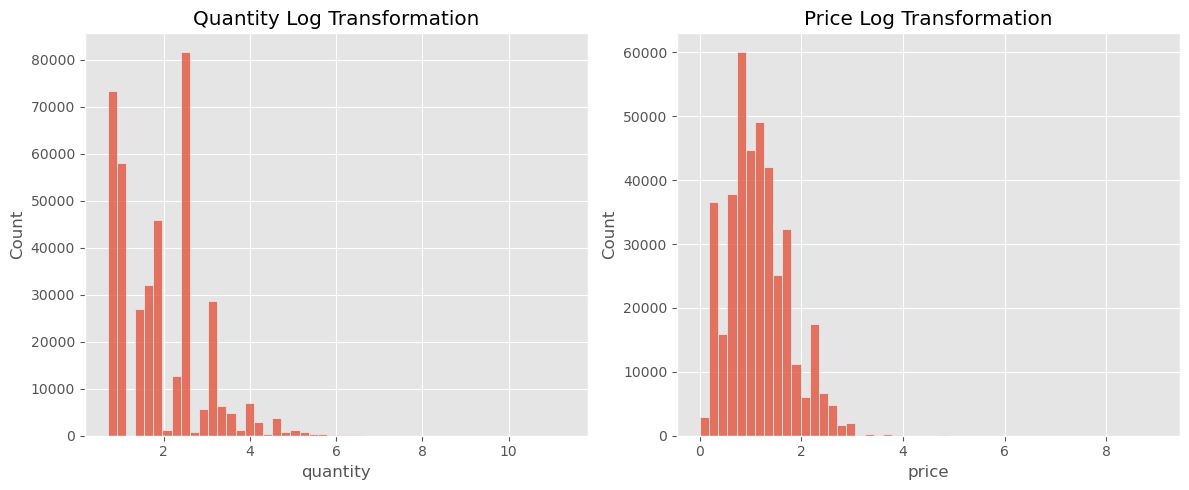

In [228]:
plt.figure(figsize=(12,5))

# Quantity Log transformation distribution
plt.subplot(1,2,1)
sns.histplot(np.log1p(customers['quantity']), bins=50, kde=False)
plt.title('Quantity Log Transformation')


# Price Log transformation distribution
plt.subplot(1,2,2)
sns.histplot(np.log1p(customers['price']), bins=50, kde=False)
plt.title('Price Log Transformation')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Insights:** The distribution of both Quantity and Price show that the data is right skewed. Most of the purchases are concentrated on lower quantities and prices, with a few high value outliers on the right. 

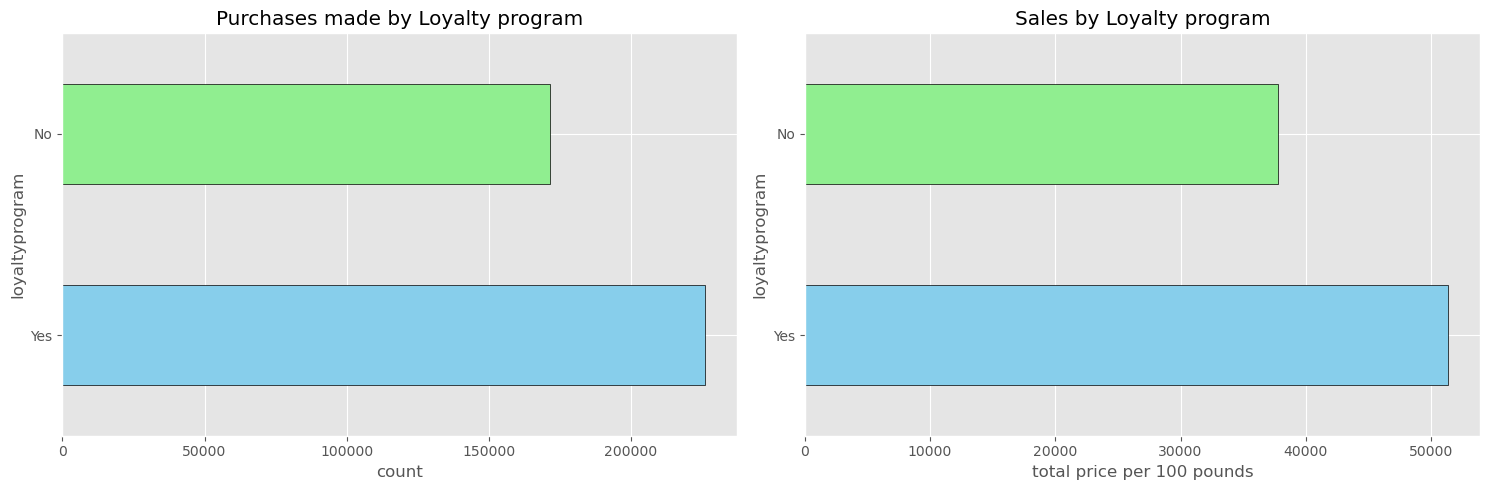

In [272]:
# count and ROI of Loyalty program distributions
#bar graphs for loyalty program

plt.figure(figsize=(15,5))

#count of Loyalty program
plt.subplot(1,2,1)
loyalty_colors = ['skyblue', 'lightgreen']  # Assign colors for loyalty program
customers_loyalty=customers['loyaltyprogram'].value_counts().sort_values(ascending=False)
customers_loyalty.plot(kind='barh', title='Purchases made by Loyalty program', xlabel='count', color=loyalty_colors, edgecolor='black')

#sales from Loyalty program
plt.subplot(1,2,2)
loyalty_colors = ['skyblue', 'lightgreen']  # Assign colors for loyalty program
customers['loyalty_totalprice']= customers['totalprice'] / 100.00
customers_loyalty=customers.groupby('loyaltyprogram')['loyalty_totalprice'].sum().sort_values(ascending=False)
customers_loyalty.plot(kind='barh', title='Sales by Loyalty program', xlabel='total price per 100 pounds', color=loyalty_colors, edgecolor='black')

plt.tight_layout()
plt.show()

**Insights:** The Customers enrolled in the Loyalty program made more purchases and generated significant sales than customers who were not enrolled.

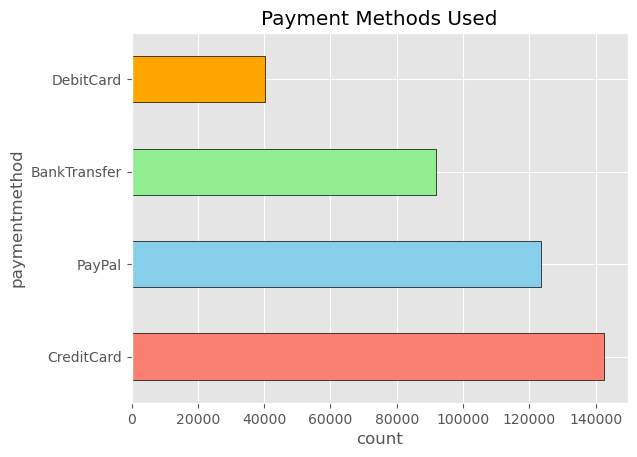

In [248]:
#payment methods
payment_colors = ['salmon', 'skyblue', 'lightgreen', 'orange']  # Assign colors for each payment method
customers_payment=customers['paymentmethod'].value_counts()
customers_payment.plot(kind='barh', title='Payment Methods Used', xlabel='count', color=payment_colors, edgecolor='black')

plt.show()

**Insights:** Most customers use Credit card for their purchases, followed by Paypal. Debit cards are the least used payment method for customers.

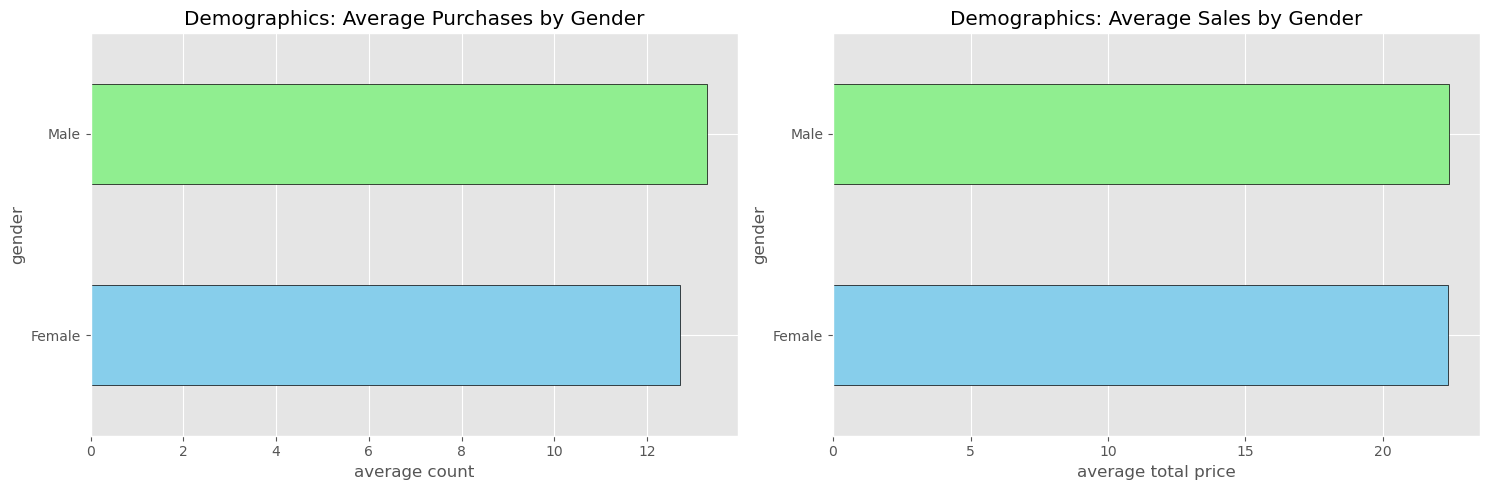

In [226]:
#Demographics: Gender

plt.figure(figsize=(15,5))

#quantity purchased
plt.subplot(1,2,1)
gender_colors = ['skyblue', 'lightgreen']  # Assign colors for gender
customers_gender= customers.groupby('gender')['quantity'].mean()
customers_gender.plot(kind='barh', title='Demographics: Average Purchases by Gender', xlabel='average count', color=gender_colors, edgecolor='black')

#Sales revenue
plt.subplot(1,2,2)
gender_colors = ['skyblue', 'lightgreen']  # Assign colors for gender
customers_gender= customers.groupby('gender')['totalprice'].mean()
customers_gender.plot(kind='barh', title='Demographics: Average Sales by Gender', xlabel='average total price', color=gender_colors, edgecolor='black')

plt.tight_layout()
plt.show()


**Insights:** On average, males make the most purchases than females, however females make slightly higher value purchases than men.

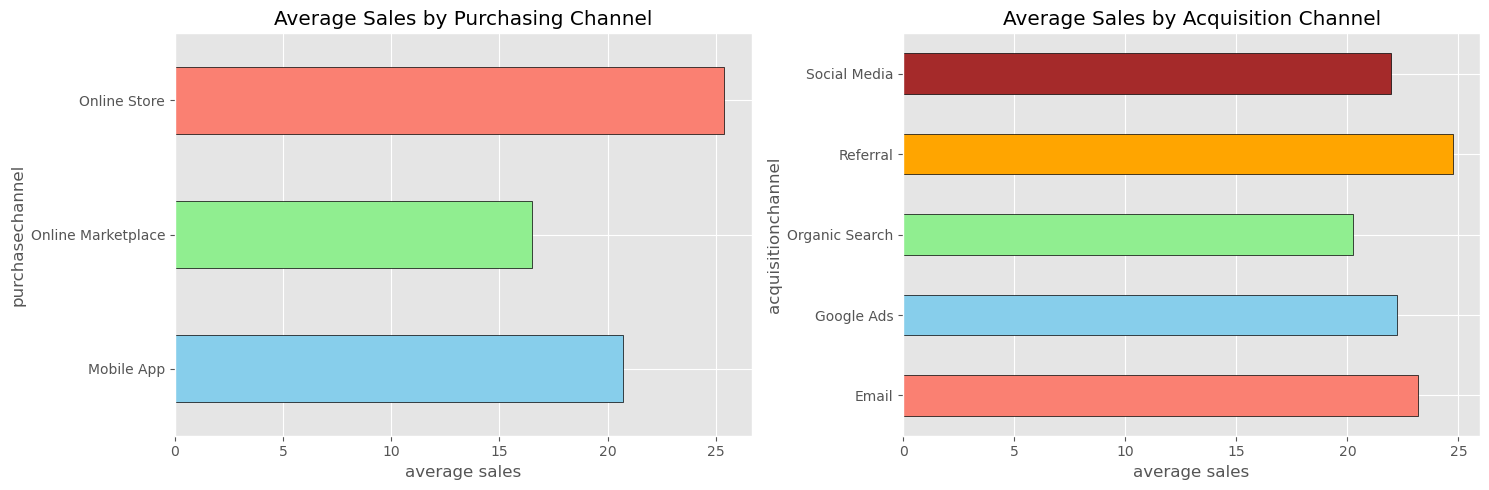

In [224]:
#sales per acquisition channel and purchase channel

plt.figure(figsize=(15,5))

#Purchasing Channel
plt.subplot(1,2,1)
purchase_colors = ['skyblue', 'lightgreen', 'salmon']  # Assign colors for purchase channel
purchase_channel=customers.groupby('purchasechannel')['totalprice'].mean()
purchase_channel.plot(kind='barh', title='Average Sales by Purchasing Channel', xlabel='average sales', color=purchase_colors, edgecolor='black')

#Acquisition channel
plt.subplot(1,2,2)
acquisition_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']  # Assign colors for each acquisition channel
acquisition_channel=customers.groupby('acquisitionchannel')['totalprice'].mean()
acquisition_channel.plot(kind='barh', title='Average Sales by Acquisition Channel', xlabel='average sales', color=acquisition_colors, edgecolor='black')

plt.tight_layout()
plt.show()

**Insights:** 
1. Customers make the most purchases from our online store website and the least on digital marketplaces like amazon,esty, etc.
2. Referrals drives more conversion compared to the digital channels. Invest more in SEO and SEM marketing to increase conversions from digital channels

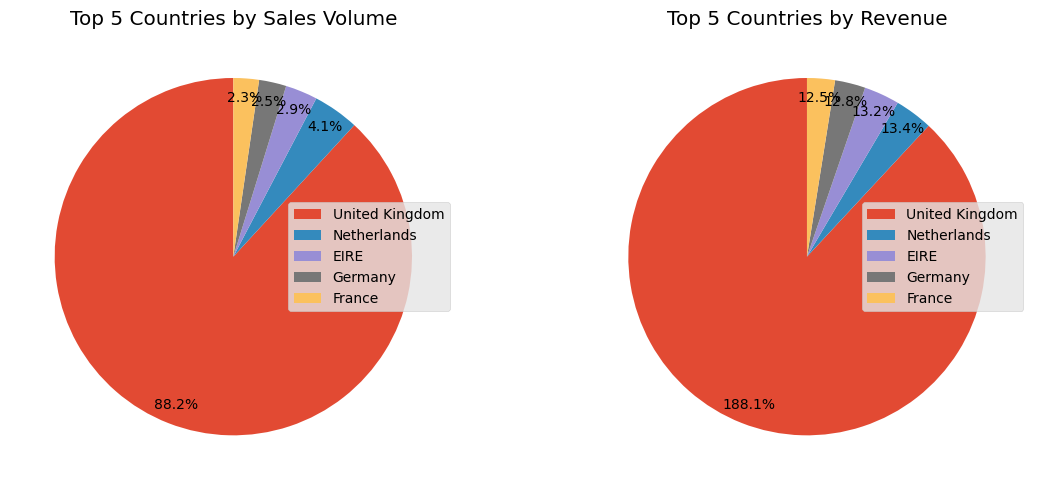

In [41]:
# Top 5 Countries by Sales
plt.figure(figsize=(12,5))


#By Volume
plt.subplot(1,2,1)
country_volume=customers.groupby('country')['quantity'].sum().sort_values(ascending=False)
top_volume=country_volume.head(5)

plt.pie(top_volume, labels=None, autopct='%1.1f%%', startangle=90, pctdistance=0.89)
plt.title("Top 5 Countries by Sales Volume")
plt.legend(top_volume.index, loc='best')


#By Value/Revenue
plt.subplot(1,2,2)
country_value=customers.groupby('country')['totalprice'].sum().sort_values(ascending=False)
top_value=country_value.head(5)

plt.pie(top_value, labels=None, autopct='1%.1f%%', startangle=90, pctdistance=0.89)
plt.title("Top 5 Countries by Revenue")
plt.legend(top_value.index, loc='best')




plt.tight_layout()
plt.show()


**Insights:** Most of NovaCart's customer base and revenue generated are from the United Kingdom, followed by Netherlands and Ireland.

**3.Bivariate/ Multivariate Analysis**

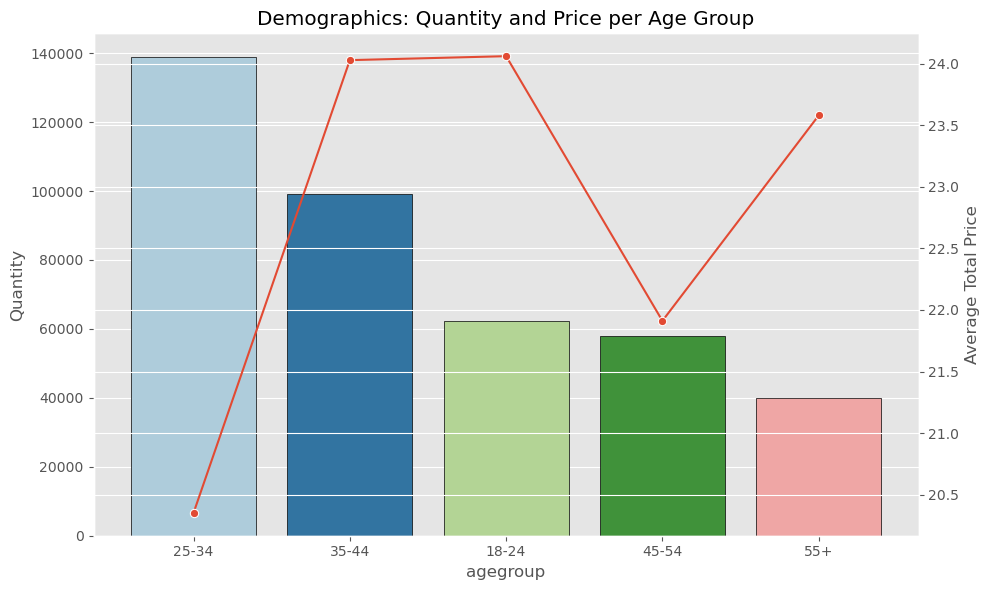

In [250]:
#Price and quantity per age group

quantity_counts= customers['agegroup'].value_counts()   #count the unique values each cluster label has in the data
totalprice_mean= customers.groupby('agegroup')['totalprice'].mean()   #take the mean of total price

#create a barplot of counts and means
fig, ax1 =plt.subplots(figsize=(10,6))

sns.barplot(x=quantity_counts.index, y=quantity_counts.values, ax=ax1, palette='Paired', hue=quantity_counts.index, edgecolor='black')
ax1.set_ylabel('Quantity')
ax1.set_title('Demographics: Quantity and Price per Age Group')

#create a secondary axis for the mean of features
ax2= ax1.twinx()

sns.lineplot(data=totalprice_mean, ax=ax2, marker='o')    #create a lineplot to represent the average of total price
ax2.set_ylabel('Average Total Price')

plt.tight_layout()
plt.show()

**Insights:**
1. Customers in the 25-34 age group make the most purchases but the lowest value in sales. This means almost all of their purchases are low value purchase. Tailor bundle packages and special offers to drive their spending levels.
2. Customers in the 18-24 age group are the highest value purchases however buys fewer items. Tailor product recommendations and special deals to increase their quantity demanded.
3. NovaCart's high value customer base by age group are 18-24 (highest sales value but average quantity demanded, 35-44 (most loyal: very high sales value and quantity), and 55+ (lowest quantity demanded but very high sales value)   

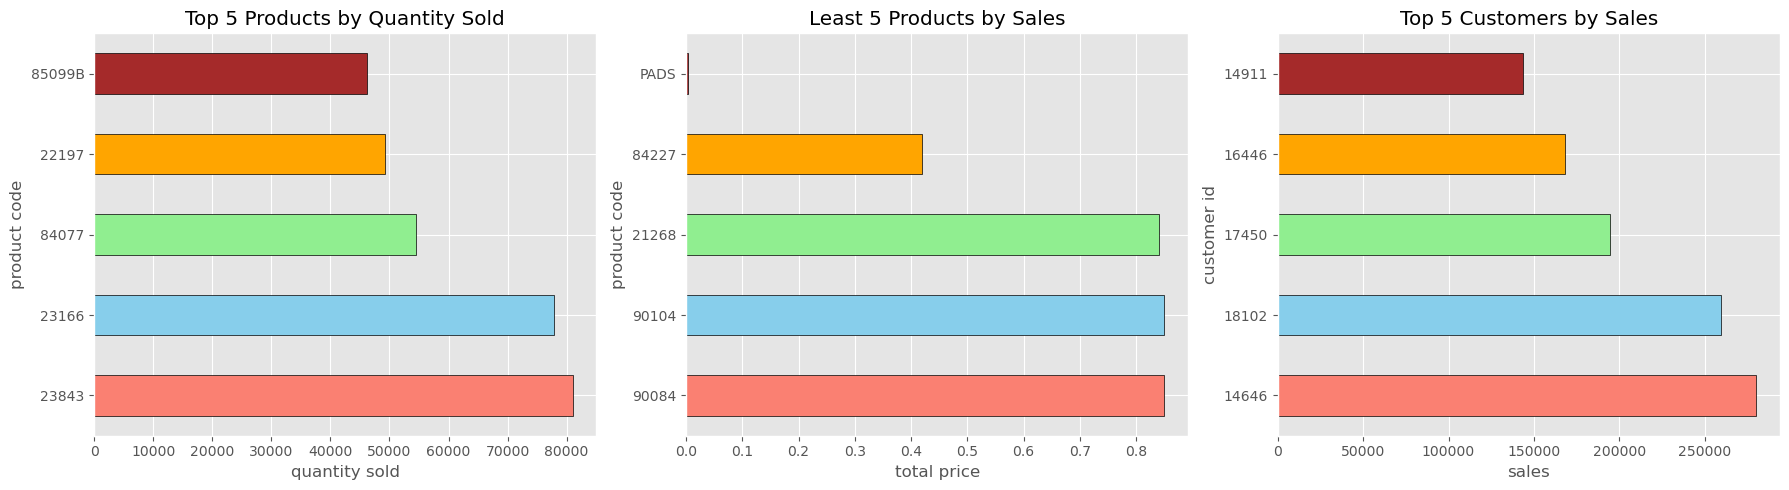

In [295]:
#Product performance
plt.figure(figsize=(18,5))

#Top 5 products by quantity sold
plt.subplot(1,3,1)
products_sold=customers.groupby('stockcode')['quantity'].sum().sort_values(ascending=False)
top_products=products_sold.head(5)
product_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']  # Assign colors for each product
top_products.plot(kind='barh', title='Top 5 Products by Quantity Sold', xlabel='quantity sold', ylabel='product code', color=product_colors, edgecolor='black')

#least 5 products by sales
plt.subplot(1,3,2)
products_sold= customers.groupby('stockcode')['totalprice'].sum().sort_values(ascending=False)
least_products= products_sold.tail(5)
product_colors= ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']  # Assign colors for each product
least_products.plot(kind='barh', title='Least 5 Products by Sales', xlabel='total price', ylabel='product code', color=product_colors, edgecolor='black')

#Top 5 customers by sales
plt.subplot(1,3,3)
customer_sales=customers.groupby('customerid')['totalprice'].sum().sort_values(ascending=False)
top_customers=customer_sales.head(5)
customer_sales_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']  # Assign colors for each product
top_customers.plot(kind='barh', title='Top 5 Customers by Sales', xlabel='sales', ylabel='customer id', color=customer_sales_colors, edgecolor='black')

plt.tight_layout()
plt.show()

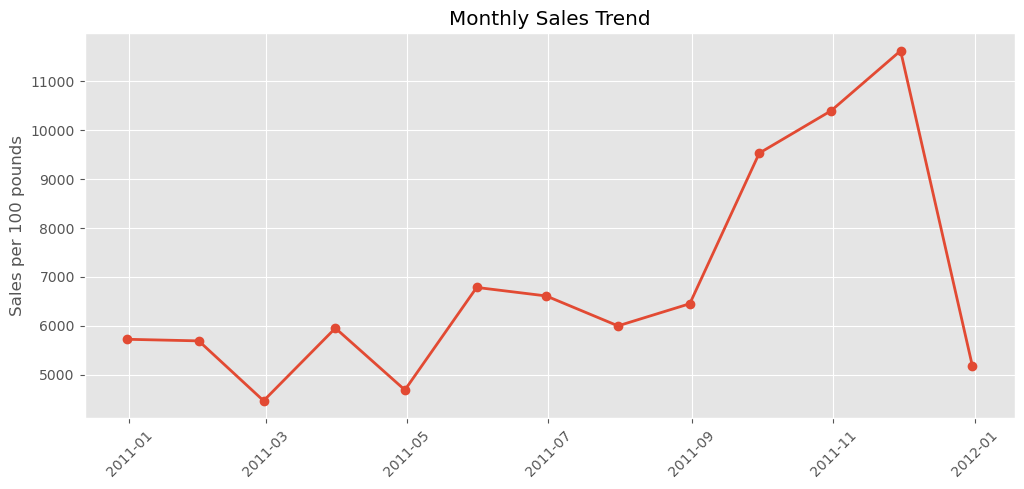

In [303]:
#Monthly Sales trend
plt.figure(figsize=(12,5))
customers['trend_totalprice']= customers['totalprice'] / 100.00
sales_trend=customers.set_index('invoicedate')['trend_totalprice'].resample('ME').sum()
plt.plot(sales_trend, marker='o', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.ylabel('Sales per 100 pounds')

plt.show()

**Insights:** Sales had been fluctuating since beginning of the year. But increases drastically from September through December. Most purchases are made toward the festive seasons from Thanksgiving to New Year's.

In [44]:
#Correlation Matrix
correlation=customers[['quantity', 'price', 'totalprice']].corr()
customers[['quantity', 'price', 'totalprice']].corr()

,quantity,price,totalprice
quantity,1.000000,-0.004563,0.914387
price,-0.004563,1.000000,0.081645
totalprice,0.914387,0.081645,1.000000


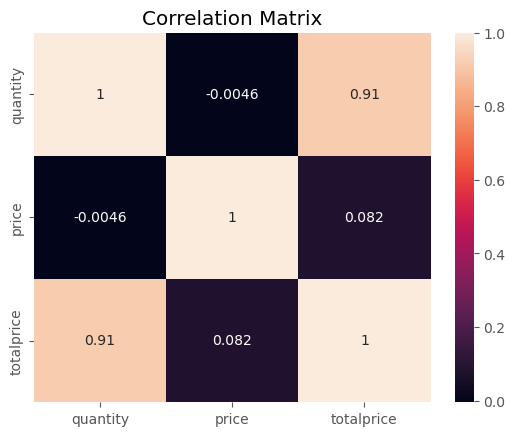

In [45]:
#Correlation Heatmap
sns.heatmap(correlation, annot=True)
plt.title('Correlation Matrix')
plt.show()

**4. Feature Engineering: Recency, Frequency, Monetary Value (RFM)**

In [48]:
#aggregating variables for RFM analysis
#Frequency and Monetary value

agg_customers=customers.groupby(by='customerid', as_index=False).agg(
    Frequency=('invoice', 'nunique'),
    MonetaryValue=('totalprice', 'sum'),
    LastInvoiceDate=('invoicedate', 'max')
)

In [49]:
agg_customers.head()

,customerid,Frequency,MonetaryValue,LastInvoiceDate
0,12346,1,77183.60,2011-01-18 10:01:00
1,12347,7,4310.00,2011-12-07 15:52:00
2,12348,4,1797.24,2011-09-25 13:13:00
3,12349,1,1757.55,2011-11-21 09:51:00
4,12350,1,334.40,2011-02-02 16:01:00


In [50]:
#Adding recency to RFM analysis

max_invoice_date=agg_customers['LastInvoiceDate'].max()
print('The last day of sales is:', max_invoice_date)
agg_customers['Recency']=(max_invoice_date - agg_customers['LastInvoiceDate']).dt.days
agg_customers

The last day of sales is: 2011-12-09 12:50:00


,customerid,Frequency,MonetaryValue,LastInvoiceDate,Recency
0,12346,1,77183.60,2011-01-18 10:01:00,325
1,12347,7,4310.00,2011-12-07 15:52:00,1
2,12348,4,1797.24,2011-09-25 13:13:00,74
3,12349,1,1757.55,2011-11-21 09:51:00,18
4,12350,1,334.40,2011-02-02 16:01:00,309
...,...,...,...,...,...
4333,18280,1,180.60,2011-03-07 09:52:00,277
4334,18281,1,80.82,2011-06-12 10:53:00,180
4335,18282,2,178.05,2011-12-02 11:43:00,7
4336,18283,16,2094.88,2011-12-06 12:02:00,3


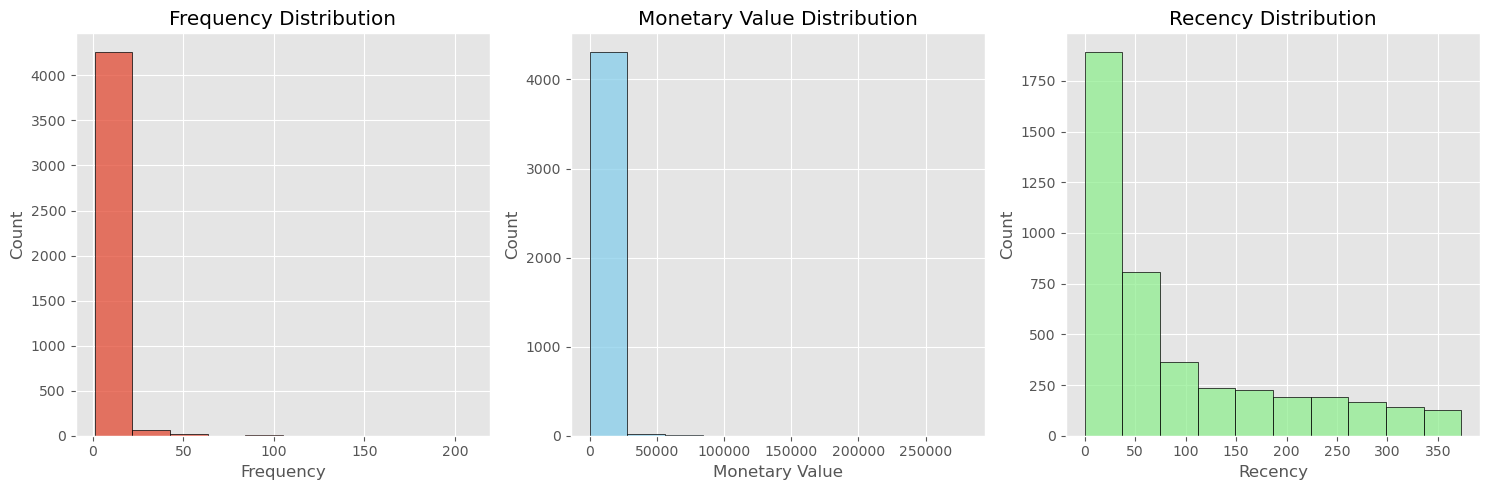

In [51]:
#Visualize agg_customers distribution

plt.figure(figsize=(15,5))

#Frequency distribution
plt.subplot(1,3,1)
sns.histplot(agg_customers['Frequency'], bins=10, edgecolor='black')
plt.xlabel('Frequency')
plt.title('Frequency Distribution')

#Monetary Value distribution
plt.subplot(1,3,2)
sns.histplot(agg_customers['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Monetary Value')
plt.title('Monetary Value Distribution')

#Recency distribution
plt.subplot(1,3,3)
sns.histplot(agg_customers['Recency'], bins=10, color='lightgreen', edgecolor='black')
plt.xlabel('Recency')
plt.title('Recency Distribution')

plt.tight_layout()
plt.show()

**Insights** Feature distributions also show the right-skewness of the data.
1. Most purchases are infrequent and of low monetary value with few outliers making high and frequent purchases.
2. Most purchases were recently made with a few scretching to almost a year from now. 

In [324]:
agg_customers.describe()

,Frequency,MonetaryValue,LastInvoiceDate,Recency
count,4338.000000,4338.000000,4338,4338.000000
mean,4.272015,2054.270609,2011-09-08 11:38:59.045643008,91.536422
min,1.000000,3.750000,2010-12-01 09:53:00,0.000000
25%,1.000000,307.415000,2011-07-20 19:18:00,17.000000
50%,2.000000,674.485000,2011-10-20 10:40:30,50.000000
75%,5.000000,1661.740000,2011-11-22 11:05:45,141.000000
max,209.000000,280206.020000,2011-12-09 12:50:00,373.000000
std,7.697998,8989.229895,NaN,100.014169


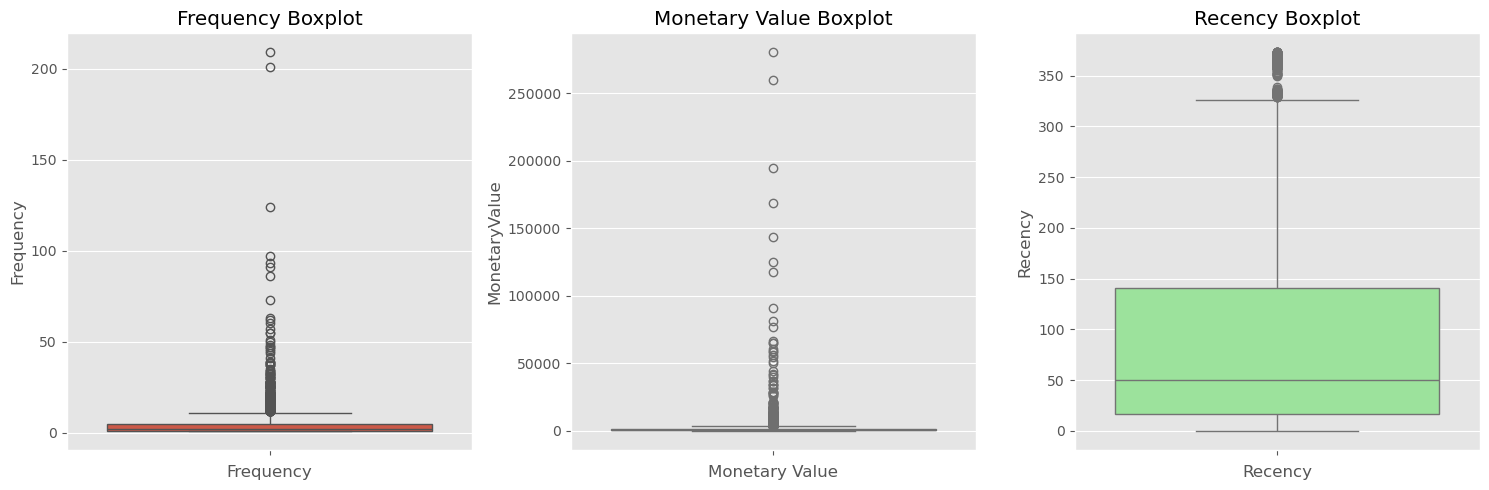

In [52]:
#Boxplot visualizations
#the boxplot vividly shows how skewed our data is and the outliers in the data

plt.figure(figsize=(15,5))

#Frequency boxplot
plt.subplot(1,3,1)
sns.boxplot(agg_customers['Frequency'])
plt.xlabel('Frequency')
plt.title('Frequency Boxplot')

#Monetary Value boxplot
plt.subplot(1,3,2)
sns.boxplot(agg_customers['MonetaryValue'], color='skyblue')
plt.xlabel('Monetary Value')
plt.title('Monetary Value Boxplot')

#Recency boxplot
plt.subplot(1,3,3)
sns.boxplot(agg_customers['Recency'], color='lightgreen')
plt.xlabel('Recency')
plt.title('Recency Boxplot')

plt.tight_layout()
plt.show()

**Insights** Outliers are high value customers and need to be analysed further to uncover insights

In [53]:
#Filtering out outliers from data
#These outliers are very vital because they are the high spenders and frequent spenders (1. spend a lot, 2. frequently spend, 3. requently spend a lot)
#Monetary Outliers
M_Q1= agg_customers['MonetaryValue'].quantile(0.25)
M_Q3= agg_customers['MonetaryValue'].quantile(0.75)
M_IQR=M_Q3 - M_Q1

monetary_outliers= agg_customers[(agg_customers['MonetaryValue'] > (M_Q3 + 1.5 * M_IQR)) | (agg_customers['MonetaryValue'] < (M_Q1 - 1.5 * M_IQR))].copy()
monetary_outliers.describe()

,Frequency,MonetaryValue,LastInvoiceDate,Recency
count,427.000000,427.000000,427,427.000000
mean,16.749415,12748.716651,2011-11-14 20:26:22.201405184,24.222482
min,1.000000,3703.290000,2010-12-02 15:27:00,0.000000
25%,7.000000,4463.535000,2011-11-16 10:33:00,3.000000
50%,12.000000,5900.280000,2011-11-29 11:46:00,10.000000
75%,19.000000,9780.115000,2011-12-06 12:07:30,23.000000
max,209.000000,280206.020000,2011-12-09 12:49:00,371.000000
std,19.234907,26252.841780,NaN,45.694224


In [54]:
#Frequency Outliers
F_Q1= agg_customers['Frequency'].quantile(0.25)
F_Q3= agg_customers['Frequency'].quantile(0.75)
F_IQR= F_Q3 - F_Q1

frequency_outliers= agg_customers[(agg_customers['Frequency'] > (F_Q3 + 1.5 * F_IQR)) | (agg_customers['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()
frequency_outliers.describe()

,Frequency,MonetaryValue,LastInvoiceDate,Recency
count,285.000000,285.000000,285,285.000000
mean,22.954386,14540.277053,2011-11-25 10:47:56.421052672,13.631579
min,12.000000,1296.440000,2010-12-02 15:27:00,0.000000
25%,13.000000,4206.390000,2011-11-23 15:39:00,2.000000
50%,17.000000,6328.050000,2011-12-02 15:22:00,6.000000
75%,24.000000,11138.710000,2011-12-07 11:35:00,15.000000
max,209.000000,280206.020000,2011-12-09 12:49:00,371.000000
std,21.202777,30071.664202,NaN,30.695822


**5. Non-Outlier RFM Analysis**

In [56]:
#Filter out the non outliers for analysis
#~ means not/negative/opposite

non_outliers= agg_customers[(~agg_customers.index.isin(monetary_outliers.index)) & (~agg_customers.index.isin(frequency_outliers.index))]
non_outliers.describe()


,Frequency,MonetaryValue,LastInvoiceDate,Recency
count,3864.000000,3864.000000,3864,3864.000000
mean,2.767598,865.249729,2011-08-31 04:13:42.127329024,99.839027
min,1.000000,3.750000,2010-12-01 09:53:00,0.000000
25%,1.000000,280.547500,2011-07-03 01:14:00,21.000000
50%,2.000000,576.130000,2011-10-11 14:37:30,58.000000
75%,4.000000,1202.397500,2011-11-17 13:09:15,159.250000
max,11.000000,3692.280000,2011-12-09 12:50:00,373.000000
std,2.176600,807.691620,NaN,101.746962


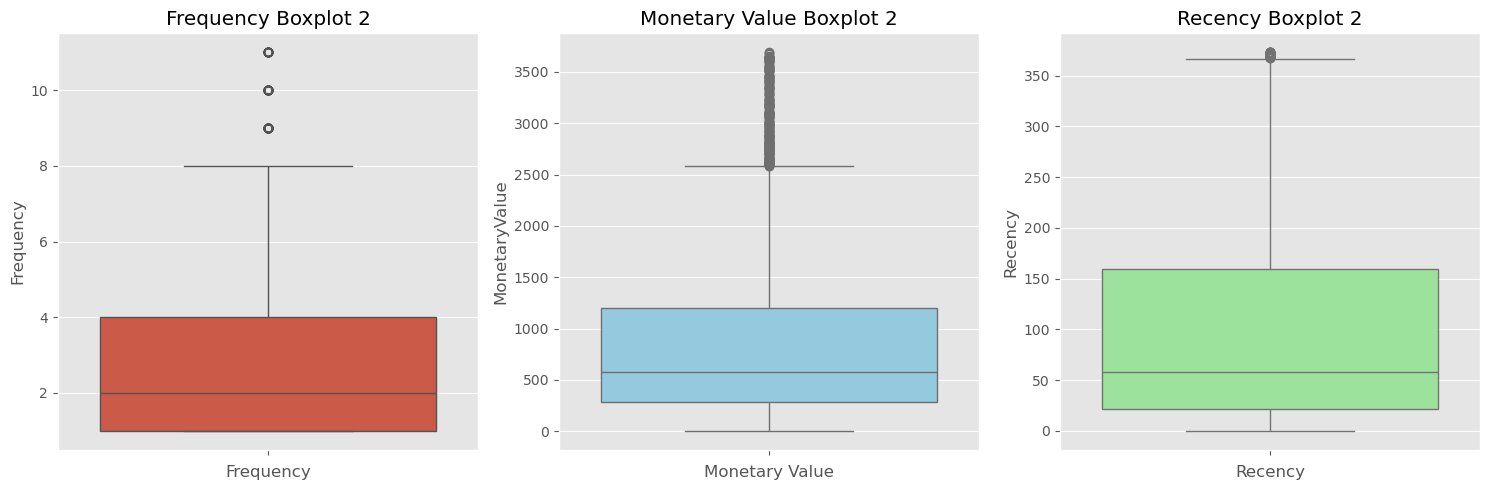

In [57]:
#Validate our non outliers using boxplot
plt.figure(figsize=(15,5))

#Frequency boxplot
plt.subplot(1,3,1)
sns.boxplot(non_outliers['Frequency'])
plt.xlabel('Frequency')
plt.title('Frequency Boxplot 2')

#Monetary Value boxplot
plt.subplot(1,3,2)
sns.boxplot(non_outliers['MonetaryValue'], color='skyblue')
plt.xlabel('Monetary Value')
plt.title('Monetary Value Boxplot 2')

#Recency boxplot
plt.subplot(1,3,3)
sns.boxplot(non_outliers['Recency'], color='lightgreen')
plt.xlabel('Recency')
plt.title('Recency Boxplot 2')

plt.tight_layout()
plt.show()


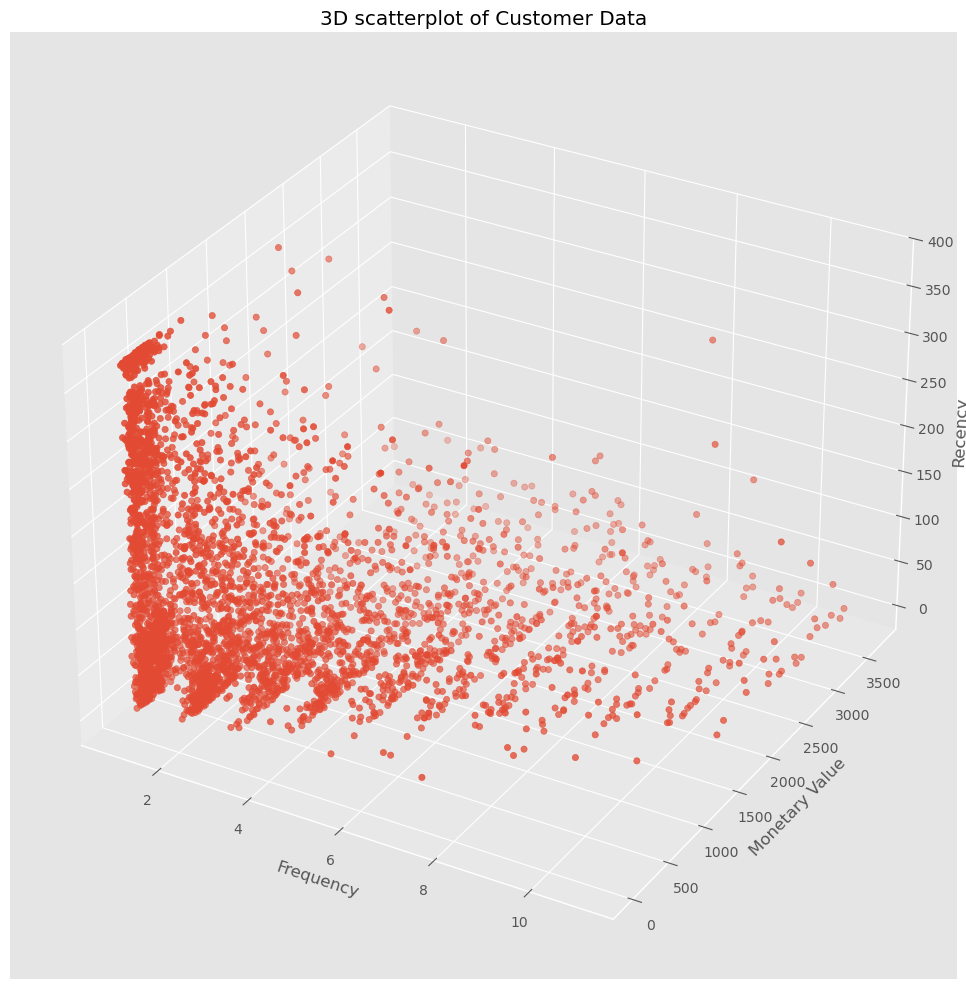

In [58]:
#visualize the 3 features on a 3D graph
#create a scatterplot for the 3 features

fig= plt.figure(figsize=(10,10))

ax= fig.add_subplot(projection='3d')

scatter=ax.scatter(non_outliers['Frequency'], non_outliers['MonetaryValue'], non_outliers['Recency'])
ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary Value')
ax.set_zlabel('Recency')
ax.set_title('3D scatterplot of Customer Data')

plt.tight_layout()
plt.show()


**5.1. Scaling Data** 
<br> **Important to Note: Using StandardScaler is prefered because although data isn't normally distributed, we are also interested in how the outliers behave. RobustScaler would eliminate these insights**

In [60]:
#since variable are on different scales, we use z score to scale data
#assume that data is normally distributed
#import sklearn scaler package

from sklearn.preprocessing import StandardScaler

In [61]:
scaler= StandardScaler()

scaled_data= scaler.fit_transform(non_outliers[['Frequency', 'MonetaryValue', 'Recency']])
scaled_data

array([[ 0.56627817,  1.15404304, -0.25398666],
       [-0.81219654,  1.10489664, -0.80444288],
       [-0.81219654, -0.65732814,  2.05596354],
       ...,
       [-0.81219654, -0.97132524,  0.78794832],
       [-0.35270497, -0.85092955, -0.91256821],
       [ 0.1067866 ,  1.20362283, -0.56853307]])

In [62]:
#convert array to dataframe

scaled_data_df= pd.DataFrame(scaled_data, index=non_outliers.index, columns=('Frequency', 'MonetaryValue', 'Recency'))
scaled_data_df

,Frequency,MonetaryValue,Recency
2,0.566278,1.154043,-0.253987
3,-0.812197,1.104897,-0.804443
4,-0.812197,-0.657328,2.055964
5,2.404244,2.031719,-0.637340
6,-0.812197,-0.961196,1.014029
...,...,...,...
4332,-0.812197,-0.856068,-0.263816
4333,-0.812197,-0.847772,1.741417
4334,-0.812197,-0.971325,0.787948
4335,-0.352705,-0.850930,-0.912568


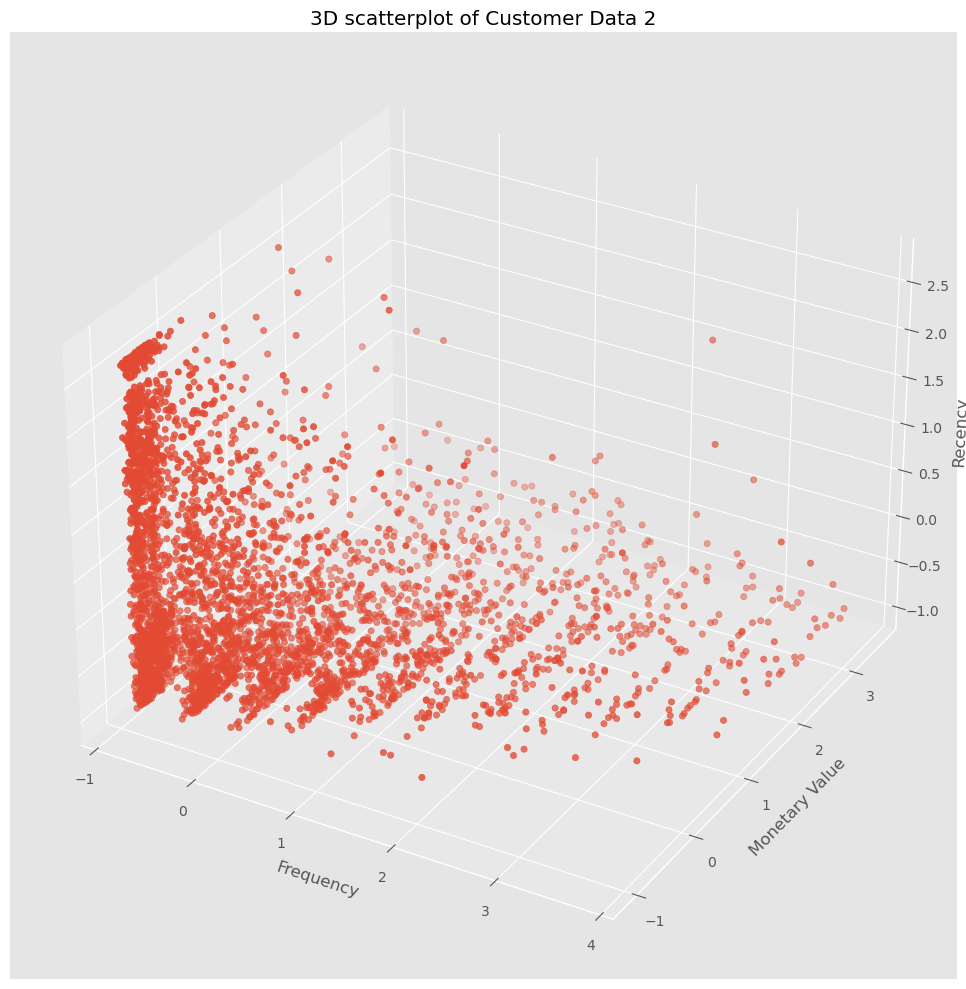

In [63]:
#validate data by plotting 3D plot with scaled data

fig= plt.figure(figsize=(10,10))

ax= fig.add_subplot(projection='3d')

scatter=ax.scatter(scaled_data_df['Frequency'], scaled_data_df['MonetaryValue'], scaled_data_df['Recency'])
ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary Value')
ax.set_zlabel('Recency')
ax.set_title('3D scatterplot of Customer Data 2')

plt.tight_layout()
plt.show()

**5.1.2. KMeans Clustering**

In [65]:
#import KMeans and silhouette score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

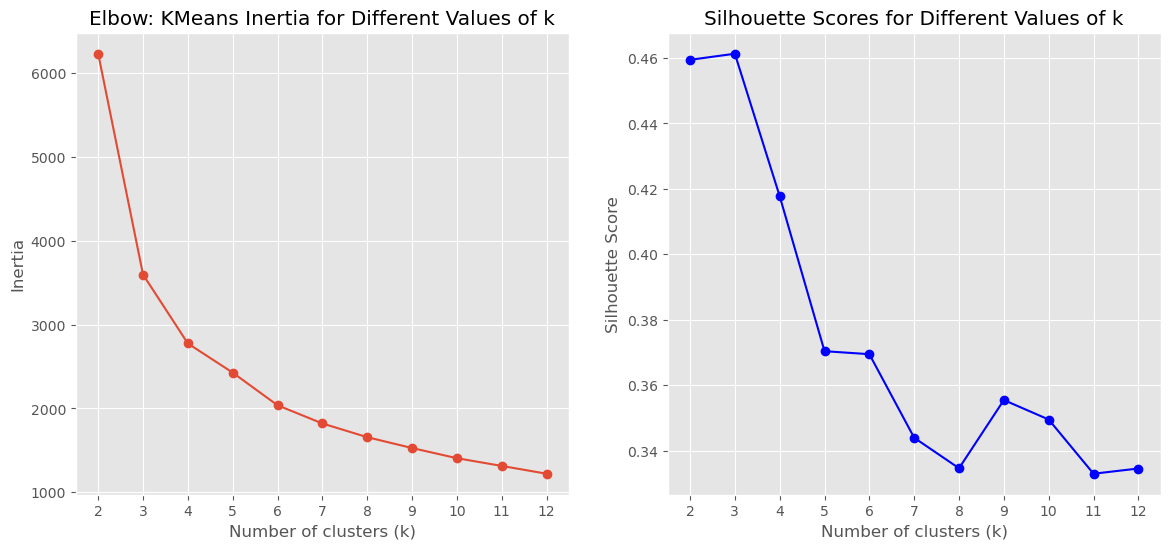

In [66]:
#use elbow method to find the right number of clusters to use
#the inertia value rapidly drops from 2 to 3 and then slows down from 4 to 5 and onwards
#the elbow showing the number of clusters for best performance is between 4 and 5
#to further validate between 3 and 4, we used the silhouette score: a metric to evaluate the quality of clustering results
#from the silhouette score, 3 has the highest score. However, using both the elbow and sil, we choose between 4 and 5.
#4 has a higher score than 5 so 4 clusters will be used for higher performance

max_k= 12
inertia= []
silhouette_scores= []

k_values= range(2, max_k + 1)

for k in k_values:
    kmeans= KMeans(n_clusters=k, random_state=42, max_iter=1000)
    
    cluster_labels= kmeans.fit_predict(scaled_data_df)
    
    sil_score= silhouette_score(scaled_data_df, cluster_labels)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(sil_score)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow: KMeans Inertia for Different Values of k')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(k_values, silhouette_scores, marker='o', color='blue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Values of k')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout
plt.show()

In [67]:
#Final KMeans model

kmeans= KMeans(n_clusters=4, random_state=42, max_iter=1000)
    
cluster_labels= kmeans.fit_predict(scaled_data_df)
cluster_labels
    

array([3, 3, 1, ..., 1, 0, 3])

In [68]:
#add cluster labels to the unscaled clustering dataframe used earlier

non_outliers['Cluster']= cluster_labels
non_outliers


C:\Users\Kwame\AppData\Local\Temp\ipykernel_16112\3357909991.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers['Cluster']= cluster_labels


,customerid,Frequency,MonetaryValue,LastInvoiceDate,Recency,Cluster
2,12348,4,1797.24,2011-09-25 13:13:00,74,3
3,12349,1,1757.55,2011-11-21 09:51:00,18,3
4,12350,1,334.40,2011-02-02 16:01:00,309,1
5,12352,8,2506.04,2011-11-03 14:37:00,35,2
6,12353,1,89.00,2011-05-19 17:47:00,203,1
...,...,...,...,...,...,...
4332,18278,1,173.90,2011-09-27 11:58:00,73,0
4333,18280,1,180.60,2011-03-07 09:52:00,277,1
4334,18281,1,80.82,2011-06-12 10:53:00,180,1
4335,18282,2,178.05,2011-12-02 11:43:00,7,0


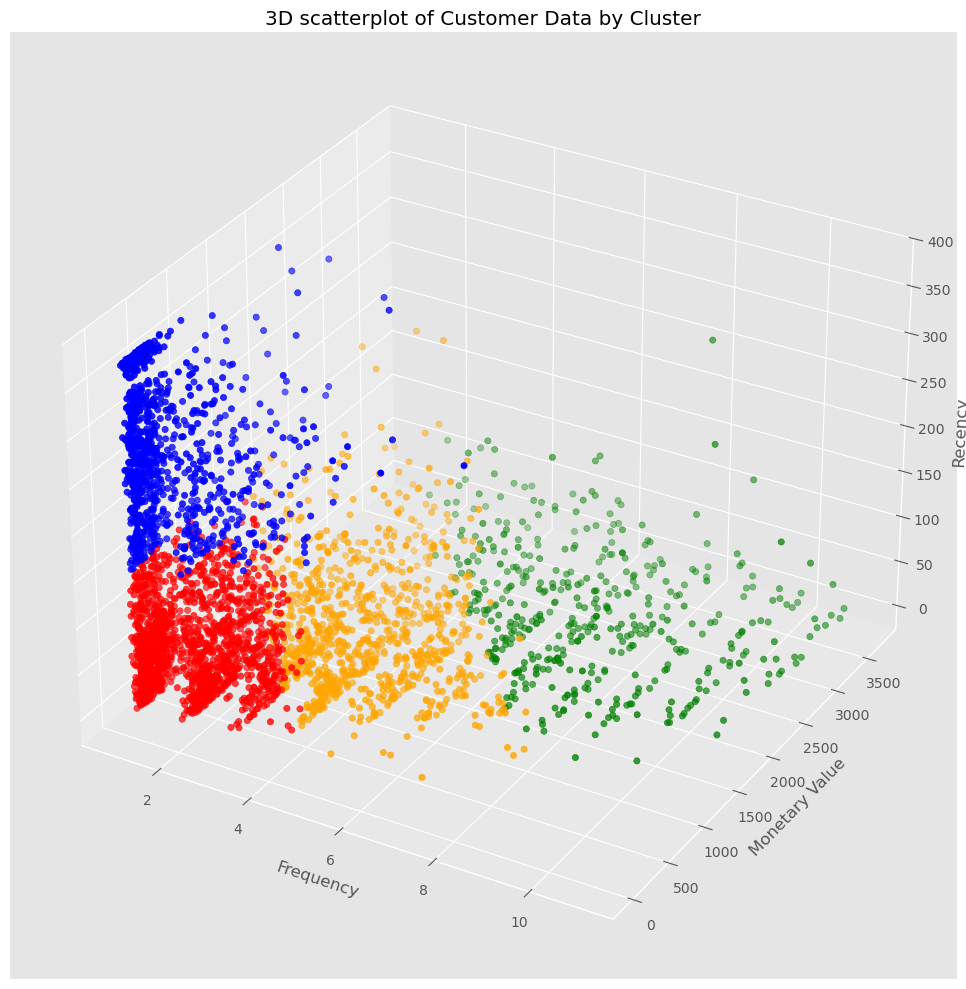

In [69]:
#visualize clustered data by plotting 3D plot with distinct colors for each cluster value

cluster_colors= {0:'red',
                 1:'blue',
                 2:'green',
                 3:'orange'
                }

colors= non_outliers['Cluster'].map(cluster_colors)

fig= plt.figure(figsize=(10,10))

ax= fig.add_subplot(projection='3d')

scatter=ax.scatter(non_outliers['Frequency'],
                   non_outliers['MonetaryValue'],
                   non_outliers['Recency'],
                   c=colors,   #mapped colors
                   marker='o')

ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary Value')
ax.set_zlabel('Recency')
ax.set_title('3D scatterplot of Customer Data by Cluster')

plt.tight_layout()
plt.show()

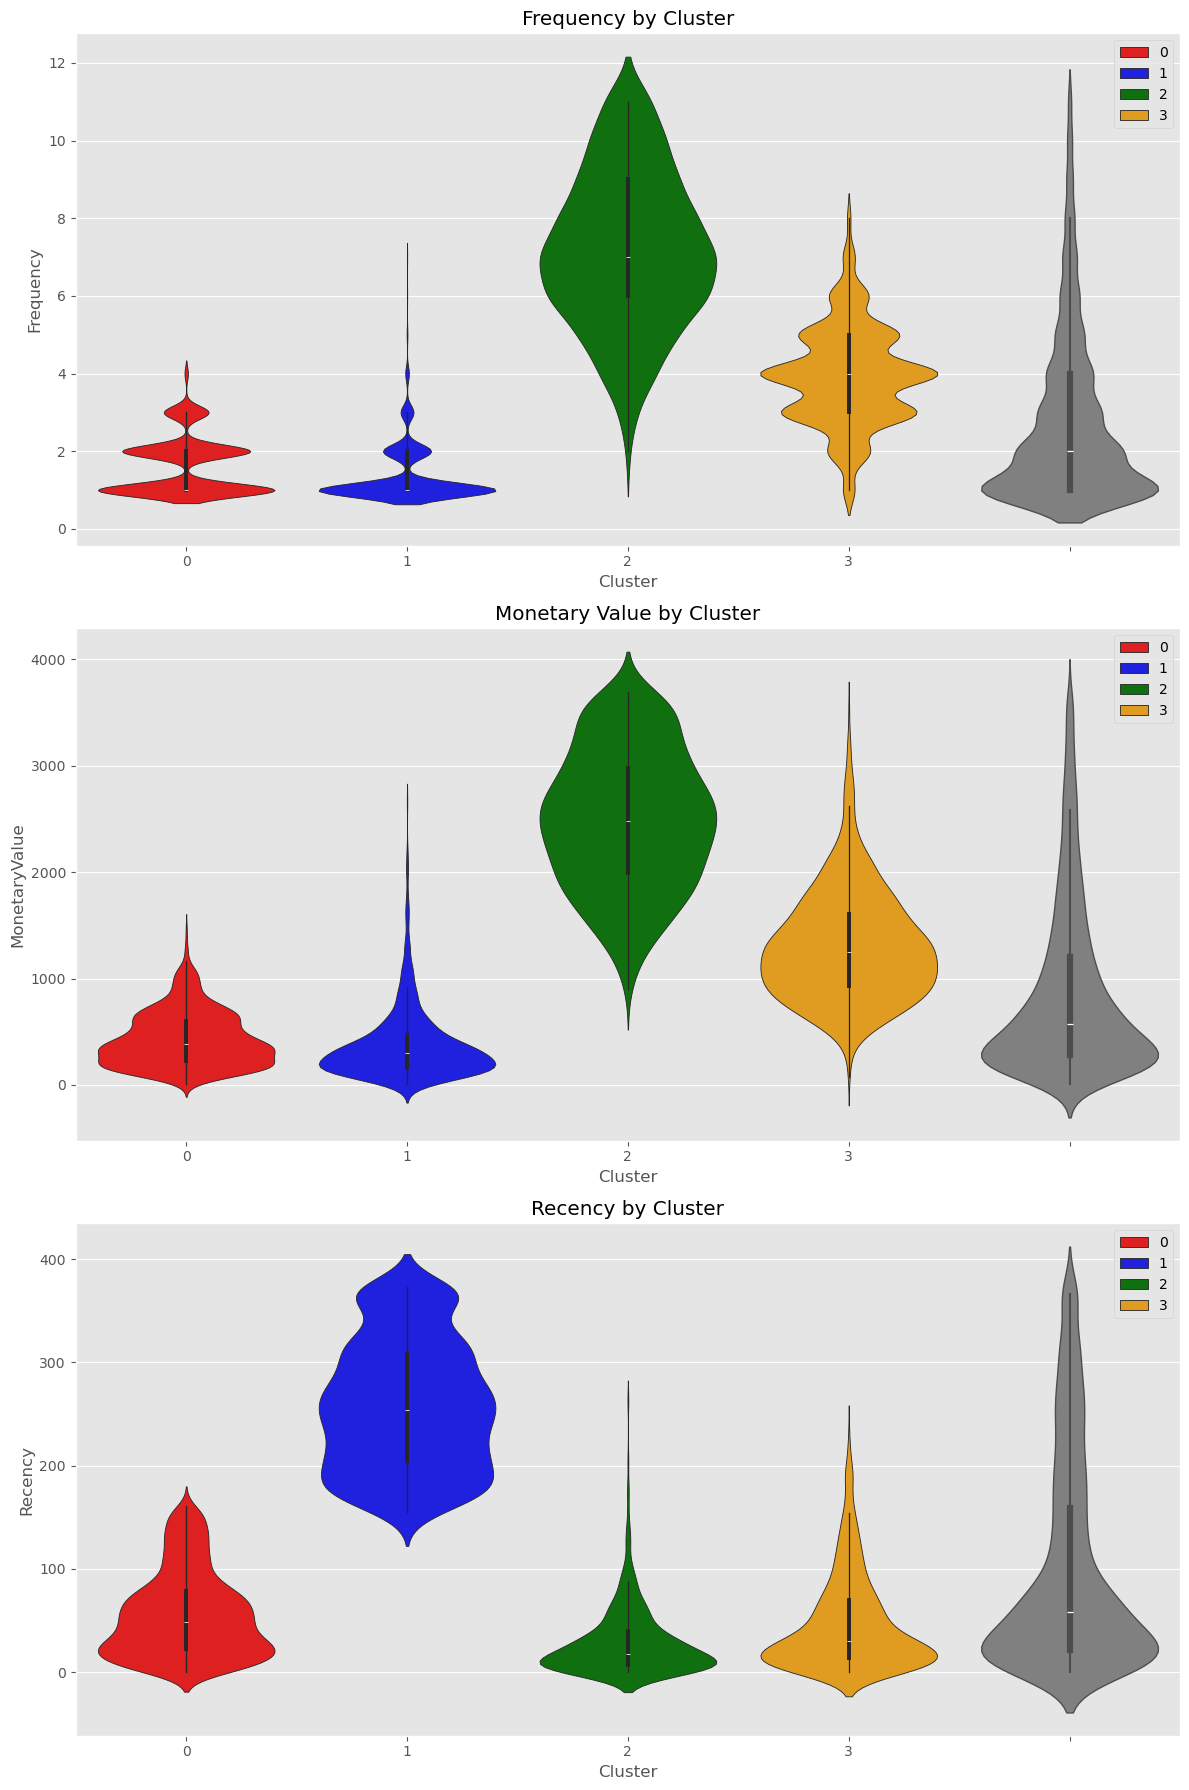

In [70]:
#Create a violinplot to visualize the clusters and their distributions
#This is helpful to visualize and provide insights for each cluster.

plt.figure(figsize=(12,18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers['Cluster'], y=non_outliers['Frequency'], palette=cluster_colors, hue=non_outliers['Cluster'])
sns.violinplot(y=non_outliers['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers['Cluster'], y=non_outliers['MonetaryValue'], palette=cluster_colors, hue=non_outliers['Cluster'])
sns.violinplot(y=non_outliers['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('MonetaryValue')

plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers['Cluster'], y=non_outliers['Recency'], palette=cluster_colors, hue=non_outliers['Cluster'])
sns.violinplot(y=non_outliers['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

**5.1.3. Summary of Clusters** 
1. Cluster 0: (red): low frequency, low monetary value, average recency (Re-engage). This cluster represents low value customers who do not purchase frequently but made some recent purchases. Some of them may be new customers and need to be nurcured and re-engaged to drive conversion, increase spending levels and engagement.
2. Cluster 1: (blue): low frequency, low monetary value, high recency (Nurture). This cluster represents low value customers who do not purchase frequently, however made purchases very recently. This may be new customers or less engaging customers who need nurturing and incentives to increase spending levels and engagement.
3. Cluster 2: (green): high frequency, high monetary value, low recency (Retain). This cluster represents very high value customers who purchase very regularly but has not made much purchases recently. More Loyalty and incentives efforts should be channelled to this group to encourage new spending and maintain loyalty.
4. Cluster 3 (orange): average frequency, average monetary value, average recency (Engage). This cluster represents high value customers who purchase regularly and some making recent purchases. Retention and Loyalty efforts should be channeled to this segment to increase engagement, spending levels and maintain loyalty.

**5.2. Outlier Analysis**

In [74]:
#Now to work with monetary outliers only, frequency outliers only, and overlap of monetary and frequency outliers.

overlap_indices= monetary_outliers.index.intersection(frequency_outliers.index)   #using their index to filter

monetary_outliers= monetary_outliers.drop(overlap_indices)
frequency_ouliers= frequency_outliers.drop(overlap_indices)
monetary_and_frequency_outliers= monetary_outliers.loc[overlap_indices]  #filtering location of overlapping outliers

In [76]:
#Manually assign clusters to outliers.
#negative numbers is just to show that these clusters were manually assigned.

monetary_outliers['Cluster']= -1
frequency_ouliers['Cluster']= -2
monetary_and_frequency_outliers['Cluster']= -3

#union the 3 outliers together to form one Outliers dataframe
outlier_clusters_df= pd.concat([monetary_outliers, frequency_ouliers, monetary_and_frequency_outliers])
outlier_clusters_df

,customerid,Frequency,MonetaryValue,LastInvoiceDate,Recency,Cluster
0,12346,1,77183.60,2011-01-18 10:01:00,325,-1
1,12347,7,4310.00,2011-12-07 15:52:00,1,-1
10,12357,1,6207.67,2011-11-06 16:07:00,32,-1
12,12359,4,6372.58,2011-10-13 12:47:00,57,-1
15,12362,10,5226.23,2011-12-06 15:40:00,2,-1
...,...,...,...,...,...,...
4291,18223,14,6484.54,2011-12-05 09:11:00,4,-2
4293,18225,12,5509.12,2011-12-06 13:27:00,2,-2
4297,18229,20,7276.90,2011-11-28 09:48:00,11,-2
4307,18241,17,2073.09,2011-11-30 12:10:00,9,-2


In [78]:
#this indicates that there's no overlapping outliers between monetary value and frequency since there's no -3 cluster records
outlier_clusters_df['Cluster'].unique()

array([-1, -2], dtype=int64)

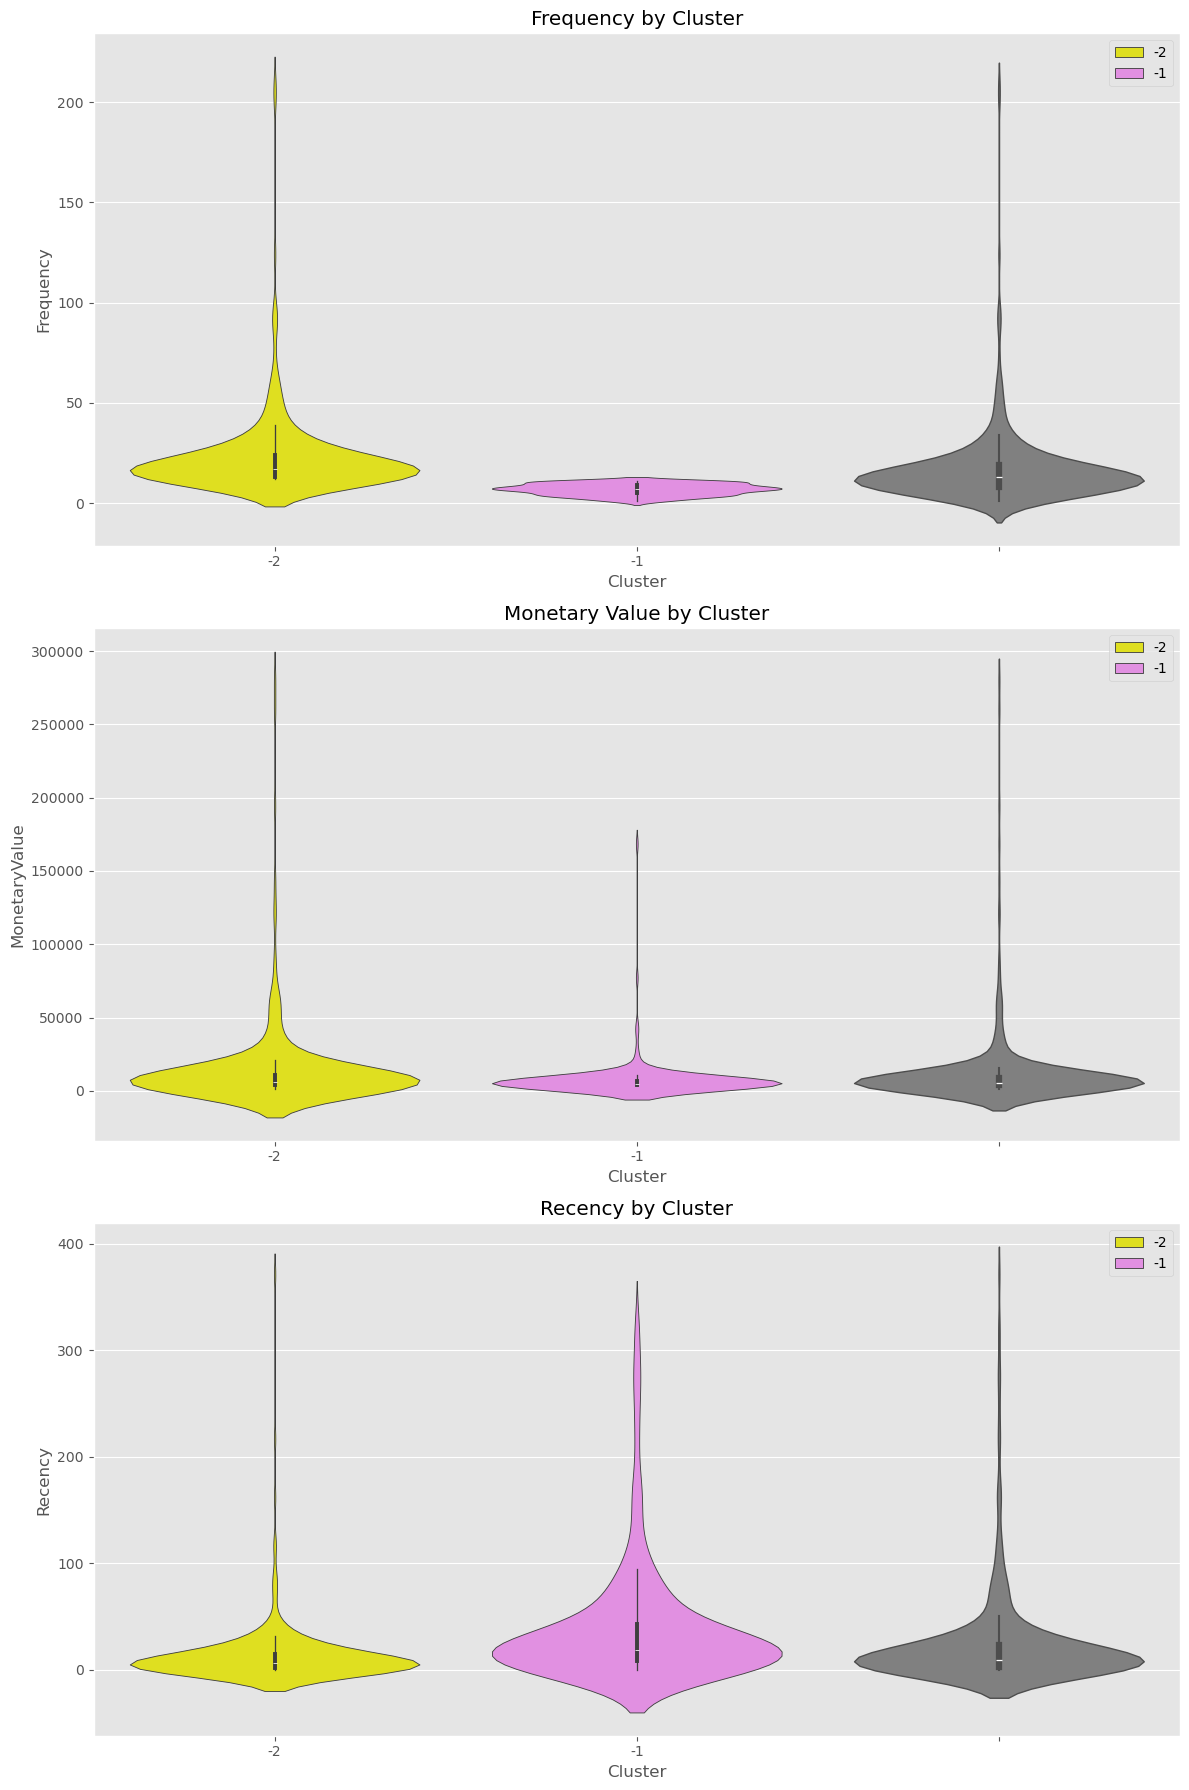

In [80]:
#Create a violinplot to visualize the outlier clusters and their distributions
#This is helpful to visualize and provide insights for each cluster.
#changed the colors for outlier clusters
#no overlaps will be shown in the violinplot

cluster_colors2= {-1:'violet',
                 -2:'yellow',
                 -3:'brown'}

plt.figure(figsize=(12,18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors2, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors2, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('MonetaryValue')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors2, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

**5.2.1 Summary of Outlier Clusters** 
1. Cluster -1: (violet): (Pamper and Upsell) Made purchases very recently, but are infrequent and spend less on purchases. Channel loyalty programs, personalized offers, appreciation through special offers, exclusive access to them to maintain loyalty and improve frequency. Offer bundle deals as well to encourage high spending per purchase.
2. Cluster -2: (yellow): (Delight) The most valuable customers. They are the extreme spenders: spend the most per purchase and are constantly making purchases. These top-tier customers need VIP treatment and special offers such as VIP programs, exclusive and member-only offers to maintain their loyalty and continued brand engagement.

**6. Combining Outlier and Non-outlier data**

In [82]:
#we will assign each cluster summary label in the data
#first create a dictionary of cluster labels to map business insight labels to data

cluster_labels= {0: 'RE-ENGAGE',
                 1: 'NURTURE',
                 2: 'RETAIN',
                 3: 'ENGAGE',
                 -1: 'PAMPER',
                 -2: 'DELIGHT'
                }

In [84]:
#combine all the cluster data

full_cluster=pd.concat([non_outliers, outlier_clusters_df])
full_cluster

,customerid,Frequency,MonetaryValue,LastInvoiceDate,Recency,Cluster
2,12348,4,1797.24,2011-09-25 13:13:00,74,3
3,12349,1,1757.55,2011-11-21 09:51:00,18,3
4,12350,1,334.40,2011-02-02 16:01:00,309,1
5,12352,8,2506.04,2011-11-03 14:37:00,35,2
6,12353,1,89.00,2011-05-19 17:47:00,203,1
...,...,...,...,...,...,...
4291,18223,14,6484.54,2011-12-05 09:11:00,4,-2
4293,18225,12,5509.12,2011-12-06 13:27:00,2,-2
4297,18229,20,7276.90,2011-11-28 09:48:00,11,-2
4307,18241,17,2073.09,2011-11-30 12:10:00,9,-2


In [86]:
#map insight labels to full cluster data

full_cluster['ClusterLabel']= full_cluster['Cluster'].map(cluster_labels)
full_cluster.head()

,customerid,Frequency,MonetaryValue,LastInvoiceDate,Recency,Cluster,ClusterLabel
2,12348,4,1797.24,2011-09-25 13:13:00,74,3,ENGAGE
3,12349,1,1757.55,2011-11-21 09:51:00,18,3,ENGAGE
4,12350,1,334.40,2011-02-02 16:01:00,309,1,NURTURE
5,12352,8,2506.04,2011-11-03 14:37:00,35,2,RETAIN
6,12353,1,89.00,2011-05-19 17:47:00,203,1,NURTURE


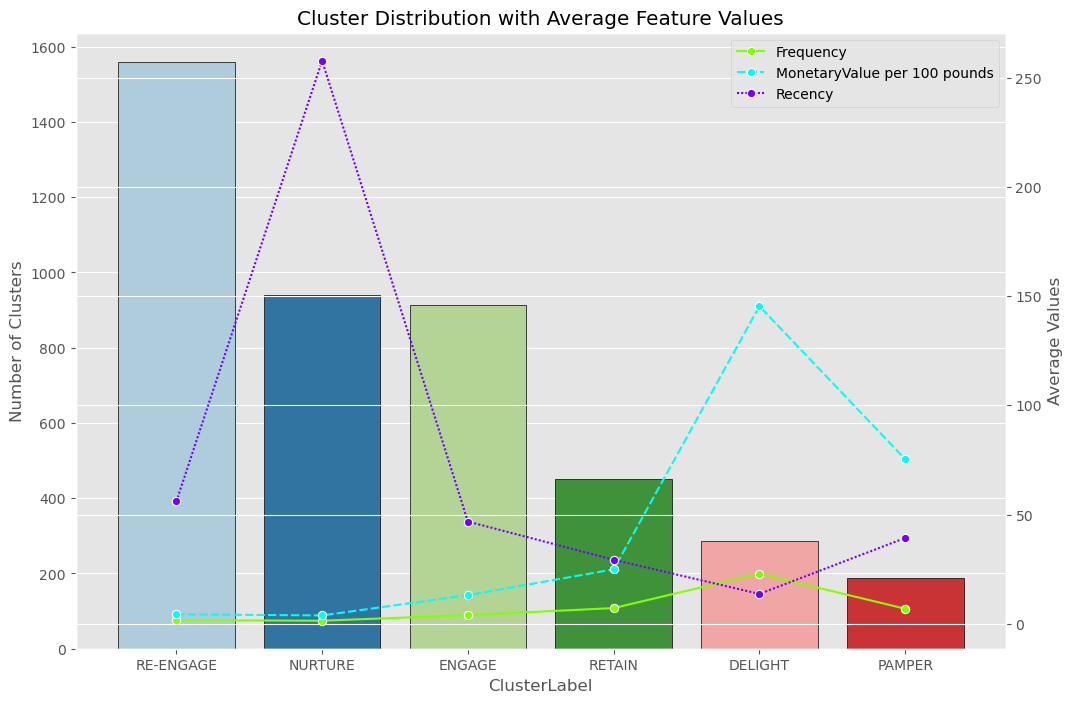

In [108]:
#now lets visualize our insights

cluster_counts= full_cluster['ClusterLabel'].value_counts()   #count the unique values each cluster label has in the data
full_cluster['MonetaryValue per 100 pounds']= full_cluster['MonetaryValue'] / 100.00
feature_mean= full_cluster.groupby('ClusterLabel')[['Frequency', 'MonetaryValue per 100 pounds', 'Recency']].mean()    #take the mean of our features

#create a barplot of counts and means
fig, ax1 =plt.subplots(figsize=(12,8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='Paired', hue=cluster_counts.index, edgecolor='black')
ax1.set_ylabel('Number of Clusters')
ax1.set_title('Cluster Distribution with Average Feature Values')

#create a secondary axis for the mean of features
ax2= ax1.twinx()

sns.lineplot(data=feature_mean, ax=ax2, palette='hsv', marker='o')    #create a lineplot to represent the means(averages) of the features
ax2.set_ylabel('Average Values')

plt.show()

**INSIGHTS FROM ANALYSIS** 
<br> This visual shows the Customer Segmentation and Behavior Analysis for NovaCart. This RFM and KMeans cluster analysis groups customers into different segments (clusters) based on their purchasing behavior (recency, frequency, monetary value). 
1. RE-ENGAGE has the highest number of customers, meaning more re-engagement efforts need to be implemented to increase the frequency and spending levels of these customers.
2. NURTURE represents customers whose purchases are most recent however, do not make high value purchase and are infrequent. Nurturing efforts need to tailored to them to encourage frequent and valued purchases.
3. DELIGHT are our High Value customers with the highest monetary value per purchases. Special offers and VIP programs should be tailored to them to encourage recent purchases and maintain their loyalty.

This RFM and Cluster analysis identifies the distinct customer groups of NovaCart, providing us data-driven insights to tailor our Retention and Expansion marketing strategies for increased ROI, sales, revenue, and customer loyalty. 

In [313]:
#validate robustness of model

from sklearn.metrics import calinski_harabasz_score

#Keep only numeric columns for the CH score
numeric_data= scaled_data_df.select_dtypes(include=['number'])

#Compute the CH index
ch_score= calinski_harabasz_score(numeric_data, kmeans.labels_)
print("CH Index:", ch_score)

CH Index: 4088.540134306448


In [317]:
#Validate model by comparing various number of k and their CH Index
#From the results, our k of 4 is very good, making the model robust.

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(scaled_data_df)
    ch = calinski_harabasz_score(scaled_data_df, kmeans.labels_)
    print(f"k={k}, CH Index={ch:.2f}")

k=2, CH Index=3325.86
k=3, CH Index=4292.41
k=4, CH Index=4088.54
k=5, CH Index=3643.09
k=6, CH Index=3616.64
k=7, CH Index=3448.53
k=8, CH Index=3300.86
k=9, CH Index=3172.43


In [321]:
print('Done')

Done
